In [ ]:
"""Importing Libraries"""

#General
import pandas as pd
import numpy as np
import scipy
import scipy.io
import os
import zipfile
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import random

#Deep Learning
import imgaug.augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Input, Conv2D, Conv1D, MaxPooling1D, BatchNormalization, Dense, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape, Concatenate, Activation, Permute, Multiply, Attention, GlobalMaxPooling1D
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC

import gc

In [ ]:
"""Mounting Google Drive"""
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
directory = '/content/drive/MyDrive/Alzheimers Disease Dataset/Features/'

data_array = []

# Initialize an empty dictionary to store participant IDs and labels
labels = {}

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        # Extract participant ID from the filename
        participant_id = filename.split('_')[0].split('-')[-1]

        # Read the CSV file
        file_path = os.path.join(directory, filename)
        data = pd.read_csv(file_path)

        # Append the data to the array
        data_array.append(data.iloc[:, :1078])

        # Map participant ID to label
        if "001" <= participant_id <= "036":
            labels[participant_id] = "A"
        elif "037" <= participant_id <= "065":
            labels[participant_id] = "C"
        elif "066" <= participant_id <= "085":
            labels[participant_id] = "F"

In [ ]:
X = np.asarray(data_array)
label_array = list(labels.values())

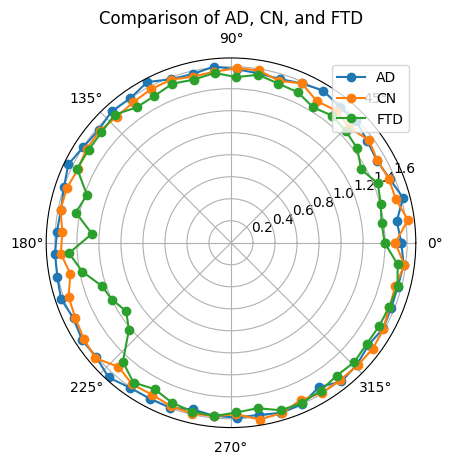

In [ ]:
# Define categories and indices
categories = ['AD', 'CN', 'FTD']
indices = [0, 15, -1]

# Set the number of features
num_features = len(X[0, 0, ::22])

# Define angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()

# Close the radar chart
angles += angles[:1]

# Create radar chart for each category
for category, index in zip(categories, indices):
    # Extract feature values
    values = X[index, 0, ::22]

    # Close the radar chart
    values = np.concatenate((values,[values[0]]))

    # Plot radar chart
    plt.polar(angles, values, marker='o', label=category)

# Add legend
plt.legend(loc='upper right')

# Set the title and show the plot
plt.title('Comparison of AD, CN, and FTD')
plt.savefig('radar_plot.pdf')
plt.show()

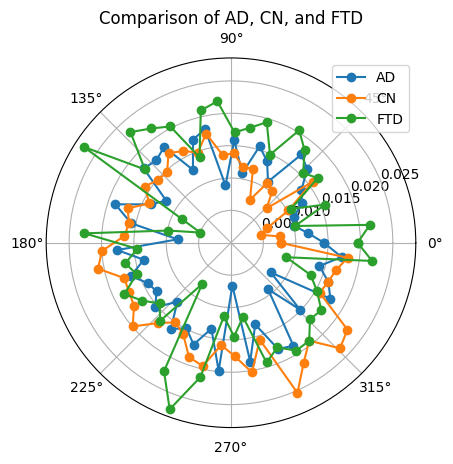

In [ ]:
# Define categories and indices
categories = ['AD', 'CN', 'FTD']
indices = [0, 5, 26]

# Set the number of features
num_features = len(X[0, 0, 1::22])

# Define angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()

# Close the radar chart
angles += angles[:1]

# Create radar chart for each category
for category, index in zip(categories, indices):
    # Extract feature values
    values = X[index, 0, 1::22]

    # Close the radar chart
    values = np.concatenate((values,[values[0]]))

    # Plot radar chart
    plt.polar(angles, values, marker='o', label=category)

# Add legend
plt.legend(loc='upper right')

# Set the title and show the plot
plt.title('Comparison of AD, CN, and FTD')
plt.savefig('radar_plot_lyap.pdf')
plt.show()

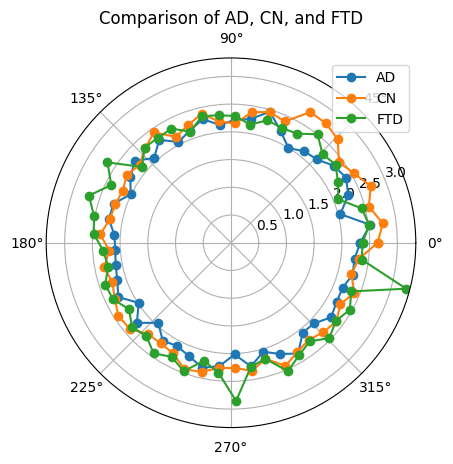

In [ ]:
# Define categories and indices
categories = ['AD', 'CN', 'FTD']
indices = [0, 5, 26]

# Set the number of features
num_features = len(X[0, 0, 2::22])

# Define angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()

# Close the radar chart
angles += angles[:1]

# Create radar chart for each category
for category, index in zip(categories, indices):
    # Extract feature values
    values = X[index, 0, 2::22]

    # Close the radar chart
    values = np.concatenate((values,[values[0]]))

    # Plot radar chart
    plt.polar(angles, values, marker='o', label=category)

# Add legend
plt.legend(loc='upper right')

# Set the title and show the plot
plt.title('Comparison of AD, CN, and FTD')
plt.savefig('radar_plot_spectral_entropy.pdf')
plt.show()

In [ ]:
label_encoder = LabelEncoder()
label_int = label_encoder.fit_transform(label_array)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Reshape features to 2D array
n_samples, n_timesteps, n_features = X.shape
features_2d = X.reshape((n_samples, n_timesteps * n_features))

# Check the class distribution before SMOTE
print("Before SMOTE:", Counter(label_int))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, label_int = smote.fit_resample(features_2d, label_int)

# Reshape the features back to the original 3D array shape
X = X_resampled.reshape((-1, n_timesteps, n_features))

# Check the class distribution after SMOTE
print("After SMOTE:", Counter(label_int))

Before SMOTE: Counter({0: 33, 1: 29, 2: 18})
After SMOTE: Counter({0: 33, 1: 33, 2: 33})


In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.5),                   # Flip images vertically
    iaa.Affine(rotate=(-5, 5)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.05)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(1):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

In [ ]:
X = X.astype(np.float32)

EEG_augmented_features, augmented_labels = DataAugmentation(X, label_int)

(198, 17, 1078)
(198,)


In [ ]:
# Standardize features
scaler = StandardScaler()
# Reshape features if necessary
features_reshaped = np.reshape(EEG_augmented_features, (EEG_augmented_features.shape[0], -1))  # Reshape features to (n_samples, n_features)
features_scaled = scaler.fit_transform(features_reshaped)  # Scale features
features_scaled = np.reshape(features_scaled, EEG_augmented_features.shape)  # Reshape back to original shape

In [ ]:
onehot_encoder = OneHotEncoder(sparse=False)
integer_encoded = augmented_labels.reshape(len(augmented_labels), 1)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.models import Model
from keras.regularizers import l2

def create_cnn_model(input_shape, num_classes, dropout_rate=0.5, l2_penalty=0.01):
    # Input layer
    input_layer = Input(shape=input_shape)

    # CNN layers
    cnn_output = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Conv1D(128, 3, activation='relu', padding='same')(cnn_output)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Flatten()(cnn_output)

    # Fully connected layers with regularization
    fc_output = Dense(128, activation='relu', kernel_regularizer=l2(l2_penalty))(cnn_output)
    fc_output = Dropout(dropout_rate)(fc_output)
    output_layer = Dense(num_classes, activation='softmax')(fc_output)

    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [ ]:
from keras.layers import Input, LSTM, GlobalMaxPooling1D, Dense, Dropout
from keras.models import Model
from keras.regularizers import l2

def create_lstm_model(input_shape, num_classes, dropout_rate=0.5, l2_penalty=0.01):
    # Input layer
    input_layer = Input(shape=input_shape)

    # LSTM layers
    lstm_output = LSTM(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(input_layer)
    lstm_output = LSTM(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(lstm_output)
    lstm_output = GlobalMaxPooling1D()(lstm_output)

    # Fully connected layers with regularization
    fc_output = Dense(128, activation='relu', kernel_regularizer=l2(l2_penalty))(lstm_output)
    fc_output = Dropout(dropout_rate)(fc_output)
    output_layer = Dense(num_classes, activation='softmax')(fc_output)

    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [ ]:
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Attention, GlobalMaxPooling1D, Concatenate, Dense, Dropout
from keras.models import Model
from keras.regularizers import l2

def create_cnn_lstm_model(input_shape, num_classes, dropout_rate=0.5, l2_penalty=0.01):
    # Input layer
    input_layer = Input(shape=input_shape)

    # CNN layers
    cnn_output = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Conv1D(128, 3, activation='relu', padding='same')(cnn_output)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Flatten()(cnn_output)

    # LSTM layers
    lstm_output = LSTM(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(input_layer)
    lstm_output = LSTM(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(lstm_output)
    lstm_output = Attention()([lstm_output, lstm_output])
    lstm_output = GlobalMaxPooling1D()(lstm_output)

    # Concatenate CNN and LSTM outputs
    combined_output = Concatenate()([cnn_output, lstm_output])

    # Fully connected layers with regularization
    fc_output = Dense(128, activation='relu', kernel_regularizer=l2(l2_penalty))(combined_output)
    fc_output = Dropout(dropout_rate)(fc_output)
    output_layer = Dense(num_classes, activation='softmax')(fc_output)

    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [ ]:
def Predictions_Scores(model, test_data, test_labels):
  predictions = model.predict(test_data)

  # Convert the predictions to class labels
  predicted_labels = np.argmax(predictions, axis=1)
  labels_test_updated = np.argmax(test_labels, axis=-1)

  cf_matrix = confusion_matrix(labels_test_updated, predicted_labels)
  plt.figure()
  ax = sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues')
  ax.set_title('Seaborn Confusion Matrix with labels\n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ')
  plt.savefig('Conf Matrix.pdf')  # Save as PDF
  ## Display the visualization of the Confusion Matrix.
  plt.show()
  accuracy = accuracy_score(labels_test_updated, predicted_labels)
  precision = precision_score(labels_test_updated, predicted_labels, average='macro')
  recall = recall_score(labels_test_updated, predicted_labels, average='macro')
  f1 = f1_score(labels_test_updated, predicted_labels,average='macro')

  print('Accuracy: %.3f' % accuracy_score(labels_test_updated, predicted_labels))
  print('Precision: %.3f' % precision_score(labels_test_updated, predicted_labels, average='macro'))
  print('Recall: %.3f' % recall_score(labels_test_updated, predicted_labels, average='macro'))
  print('F1 Score: %.3f' % f1_score(labels_test_updated, predicted_labels,average='macro'))

  return accuracy, precision, recall, f1

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 640ms/step - accuracy: 0.3316 - loss: 3.5710 - val_accuracy: 0.4250 - val_loss: 3.0442
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4348 - loss: 3.2013 - val_accuracy: 0.5500 - val_loss: 2.9808
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4198 - loss: 3.0970 - val_accuracy: 0.4750 - val_loss: 3.0005
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4648 - loss: 3.0169 - val_accuracy: 0.5000 - val_loss: 3.0029
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5651 - loss: 2.9348 - val_accuracy: 0.5000 - val_loss: 2.9889
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5648 - loss: 2.8334 - val_accuracy: 0.5250 - val_loss: 2.9680
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6470 - loss: 2.7172 - val_accuracy: 0.5250 - val_loss: 2.9443
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7050 - loss: 2.7278 - val_accuracy: 0.5500 - val_loss: 2.92

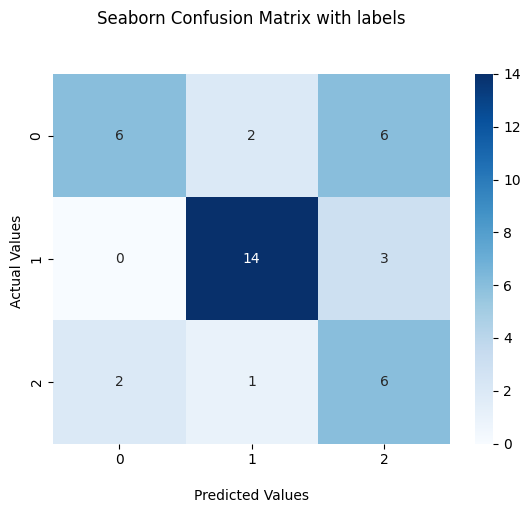

Accuracy: 0.650
Precision: 0.658
Recall: 0.640
F1 Score: 0.623


(0.65, 0.657843137254902, 0.6395891690009337, 0.622994652406417)

In [ ]:
model = create_cnn_model(input_shape=(17, 1078), num_classes=3)
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the models
batch_size = 32
epochs = 100
X_train, X_test, y_train, y_test = train_test_split(features_scaled, onehot_encoded, test_size=0.2, random_state=42)
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

Predictions_Scores(model, X_test, y_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.3464 - loss: 1.9957 - val_accuracy: 0.2750 - val_loss: 1.9929
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.2992 - loss: 1.9727 - val_accuracy: 0.2500 - val_loss: 1.9835
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2876 - loss: 2.0037 - val_accuracy: 0.2750 - val_loss: 1.9749
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2883 - loss: 1.9930 - val_accuracy: 0.2250 - val_loss: 1.9659
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3405 - loss: 1.9472 - val_accuracy: 0.2500 - val_loss: 1.9577
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3892 - loss: 1.9353 - val_accuracy: 0.2250 - val_loss: 1.9510
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3056 - loss: 1.9456 - val_accuracy: 0.2500 - val_loss: 1.9442
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3359 - loss: 1.9387 - val_accuracy: 0.2750 - val_los

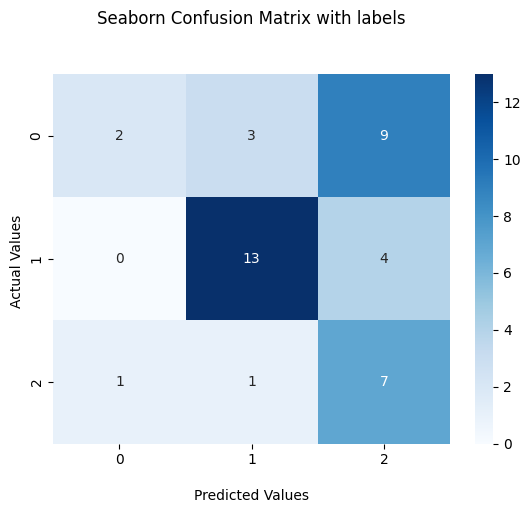

Accuracy: 0.550
Precision: 0.594
Recall: 0.562
F1 Score: 0.494


(0.55, 0.5937908496732026, 0.5617802676626206, 0.4942528735632184)

In [ ]:
model = create_lstm_model(input_shape=(17, 1078), num_classes=3)
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the models
batch_size = 32
epochs = 100
X_train, X_test, y_train, y_test = train_test_split(features_scaled, onehot_encoded, test_size=0.2, random_state=42)
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

Predictions_Scores(model, X_test, y_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.3311 - loss: 3.7092 - val_accuracy: 0.3000 - val_loss: 3.4366
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3853 - loss: 3.2558 - val_accuracy: 0.4250 - val_loss: 3.1611
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4249 - loss: 3.3401 - val_accuracy: 0.5250 - val_loss: 3.0618
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5059 - loss: 3.1024 - val_accuracy: 0.5500 - val_loss: 3.0180
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5564 - loss: 3.0696 - val_accuracy: 0.5000 - val_loss: 3.0047
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5167 - loss: 2.9454 - val_accuracy: 0.4750 - val_loss: 2.9827
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6943 - loss: 2.7946 - val_accuracy: 0.4750 - val_loss: 2.9679
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5812 - loss: 2.8629 - val_accuracy: 0.5250 - val_loss

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step


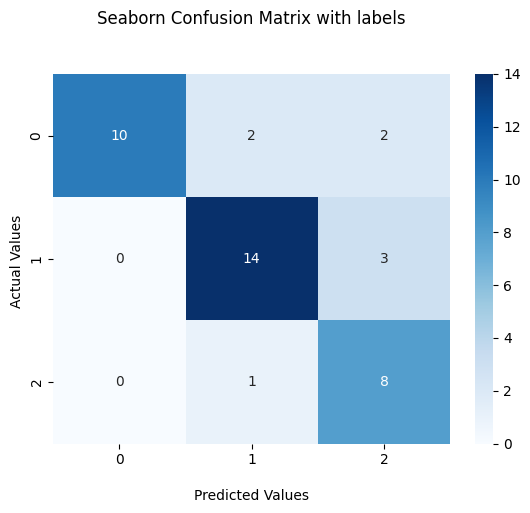

Accuracy: 0.800
Precision: 0.813
Recall: 0.809
F1 Score: 0.795


(0.8, 0.8129713423831072, 0.808901338313103, 0.7947118241235889)

In [ ]:
model = create_cnn_lstm_model(input_shape=(17, 1078), num_classes=3)
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the models
batch_size = 32
epochs = 100
X_train, X_test, y_train, y_test = train_test_split(features_scaled, onehot_encoded, test_size=0.2, random_state=42)
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

Predictions_Scores(model, X_test, y_test)